# Assignment 1: Naive Bayes Classifier, Feature Selection, and PCA
**Part 1: Categorical Dataset**

This notebook implements a complete Naive Bayes classification pipeline, explores feature selection techniques, and studies feature reduction using a custom-built Principal Component Analysis (PCA) algorithm in accordance with the assignment requirements.

**Objectives:**
1. Preprocess the categorical dataset.
2. Implement and evaluate a Baseline Naive Bayes model.
3. Apply Feature Selection and evaluate the model.
4. Implement PCA from scratch and evaluate the model.

## 1. Data Preprocessing
In this section, we load the dataset, handle missing values, and encode categorical features into numerical representations suitable for the model using `OrdinalEncoder` and `LabelEncoder`. The data is also split into training, validation, and testing sets with stratification.

In [1]:
# handling null values
# aggregations if needed
# renaming columns
# one hot encoding if needed

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from seaborn import heatmap
from sklearn.feature_selection import SelectKBest, chi2
from matplotlib import pyplot as plt

mushrooms = pd.read_csv("mushrooms.csv")
m_cols = mushrooms.columns.tolist()
mushrooms.replace({"stalk-root": "?"}, np.nan, inplace = True)
X = mushrooms.drop(columns = ["class"])
y = mushrooms["class"]


# for col in m_cols:
#     print(mushrooms[col].value_counts())

# print(mushrooms["stalk-root"].isna().sum())
# print(x)
# print(y)

# we found out this vlaue (strange one) in the stalk-root column
# stalk-root
# ?    2480
# we need to replace it with null to be able to impute it using sklearn lib methods

X_t_v, X_test, y_t_v, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y) # Stratify keeps the percentage of each class (poisnonus and eadible) equal in each set (test, validation, and traninig). That is done to protect it from bias.

X_train, X_validation, y_train, y_validation = train_test_split(
    X_t_v,
    y_t_v,
    test_size = 0.25,
    random_state = 42,
    stratify = y_t_v
)

si = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')
oe = OrdinalEncoder(handle_unknown = 'use_encoded_value', unknown_value = -1)
le = LabelEncoder()

X_train = si.fit_transform(X_train)
X_validation = si.transform(X_validation)
X_test = si.transform(X_test)

X_train = oe.fit_transform(X_train)
X_validation = oe.transform(X_validation)
X_test = oe.transform(X_test)

y_train = le.fit_transform(y_train)
y_validation = le.transform(y_validation)
y_test = le.transform(y_test)


## 2. Naive Bayes Classifier Implementation
Here, we define the core training and prediction functions for our Categorical Naive Bayes classifier. The `fit` function calculates the prior probabilities and conditional likelihoods (with Laplace smoothing). The `predict` function utilizes log probabilities to prevent numerical underflow.

In [2]:
def fit(X,y):
    classes, counts = np.unique(y, return_counts = True)
    total = 0.0
    for count in counts:
        total += count

    prior_prop_dic = dict(zip(classes, counts / total))
    lp_smoothing_factor = 1.0
    full_data = np.column_stack((X, y))

    likelihood_dic = {}

    for cls in range(2):
        cls_condition = full_data[:, -1] == cls
        cls_data = full_data[cls_condition]
        zcls_feat_num = cls_data.shape[1]

        likelihood_dic[cls] = {}
        for col in range(zcls_feat_num - 1):
            likelihood_dic[cls][col] = {}
            global_cat = np.unique(full_data[:, col])
            n_cat = len(global_cat)
            total_cls_instances = cls_data.shape[0]
            for cat in global_cat:
                cat_count = np.sum(cls_data[:, col] == cat)
                smoothed_prob = (cat_count + lp_smoothing_factor) / (total_cls_instances + (lp_smoothing_factor * n_cat))
                likelihood_dic[cls][col][cat] =  smoothed_prob 
                        
    return prior_prop_dic, likelihood_dic
    

In [3]:
def predict(X, prior, likelihood):
    final_predictions = []
    for row in X:
        zero_cls_prop = np.log(prior[0])
        one_cls_prop = np.log(prior[1])
        for idx, elm in enumerate(row):
            zero_cls_prop += np.log(likelihood[0][idx][elm])
            one_cls_prop += np.log(likelihood[1][idx][elm])

        props = [zero_cls_prop, one_cls_prop]
        final_predictions.append(np.argmax(props))

    return np.array(final_predictions)



## 3. Experiment 0: Baseline (All Features + Naive Bayes)
**Objective:** Train the Naive Bayes classifier using all original features without applying feature selection or PCA. Evaluate the model using Accuracy, Classification Report, and a Confusion Matrix to serve as a baseline reference.

0.9427692307692308
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       842
           1       0.99      0.89      0.94       783

    accuracy                           0.94      1625
   macro avg       0.95      0.94      0.94      1625
weighted avg       0.95      0.94      0.94      1625

Axes(0.125,0.11;0.62x0.77)


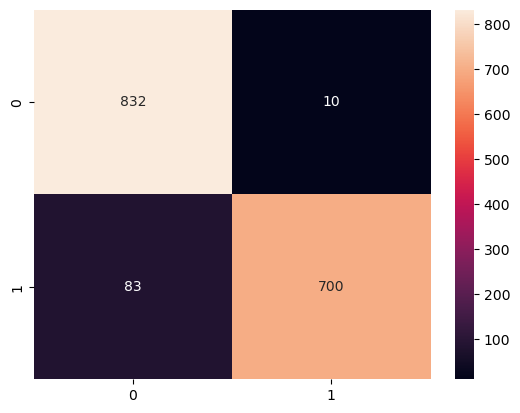

In [4]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from seaborn import heatmap
prior, likelihood = fit(X_train, y_train)
predictions = predict(X_validation, prior, likelihood)
print(accuracy_score(y_validation, predictions))
print(classification_report(y_validation, predictions))
print(heatmap(confusion_matrix(y_validation, predictions), annot = True, fmt = 'd')) # fmt -> format string, annot -> annotate
# heatmap indicates
# True Negative  | False Positive
# False Negative | True Positive

## 4. Experiment A: Feature Selection + Naive Bayes
**Objective:** Apply a feature selection technique (`SelectKBest` with `chi2`) to choose a subset of the most relevant original features. We visualize the feature scores and train the model using different feature subsets to compare against the baseline.

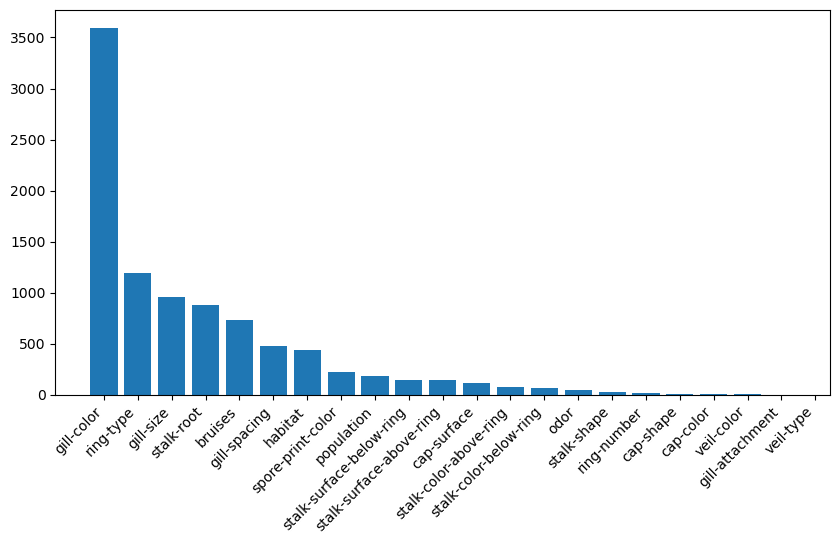

In [5]:
from sklearn.feature_selection import SelectKBest, chi2
from matplotlib import pyplot as plt
import pandas as pd
sk = SelectKBest(score_func = chi2, k = 22)
X_trial_for_plotting = sk.fit_transform(X_train, y_train)
plt.figure(figsize = (10, 5))
features_scores = pd.Series(data = sk.scores_, index = X.columns).sort_values(ascending = False)
plt.bar(features_scores.index, features_scores.values)
plt.xticks(rotation = 45, ha = 'right')
plt.show()
X_validation = sk.transform(X_validation)
X_test = sk.transform(X_test)

In [6]:
from sklearn.feature_selection import SelectKBest, chi2
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from seaborn import heatmap

k_scores = {}
for k in range(10,23):
    sk = SelectKBest(score_func = chi2, k = k) # based on the plot above
    X_train_trial = sk.fit_transform(X_train, y_train)
    X_validation_trial = sk.transform(X_validation)
    # X_test = sk.transform(X_test)
    prior, likelihood = fit(X_train_trial, y_train)
    predictions = predict(X_validation_trial, prior, likelihood)
    k_scores[k] = accuracy_score(y_validation, predictions)
    # print(classification_report(y_validation, predictions))
    # print(heatmap(confusion_matrix(y_validation, predictions), annot = True, fmt = 'd')) # fmt -> format string, annot -> annotate
    # heatmap indicates
    # True Negative  | False Positive
    # False Negative | True Positive
print(k_scores)


{10: 0.9033846153846153, 11: 0.8984615384615384, 12: 0.8990769230769231, 13: 0.8966153846153846, 14: 0.8966153846153846, 15: 0.9421538461538461, 16: 0.9403076923076923, 17: 0.9403076923076923, 18: 0.9415384615384615, 19: 0.9427692307692308, 20: 0.9427692307692308, 21: 0.9427692307692308, 22: 0.9427692307692308}


## 5. Experiment B: PCA (Feature Reduction) + Naive Bayes
**Objective:** Implement Principal Component Analysis (PCA) entirely from scratch using NumPy. Reduce dimensionality and use the resulting principal components as input to the Naive Bayes classifier to observe the impact on categorical data.

[0.33432563 0.50582329 0.63086945 0.69843011 0.75779758 0.80834259
 0.85233841 0.89099977 0.92760753 0.95349226 0.97324724 0.98197189
 0.98723903 0.99128524 0.99448509 0.99647816 0.99794494 0.99922286
 0.99969597 0.99995002 1.         1.        ]


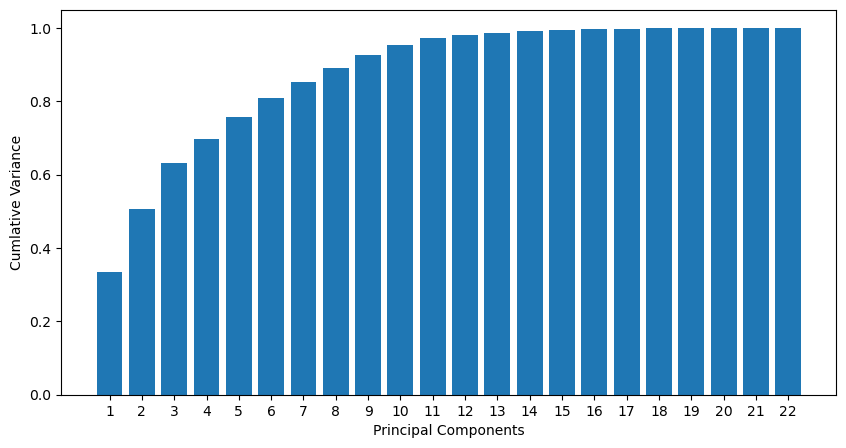

0.8738461538461538


In [7]:
def PCA(X, k):
    shifted_x = X - np.mean(X, axis = 0)
    cov_mat = np.transpose(shifted_x) @ shifted_x * 1/ (shifted_x.shape[0] - 1)
    cov_mat = np.array(cov_mat)
    eigen_values, eigen_vectors = np.linalg.eigh(cov_mat)
    dec_idx = np.argsort(eigen_values)[::-1]
    sorted_eigen_values = eigen_values[dec_idx]
    sorted_eigen_vectors = eigen_vectors[:, dec_idx]
    vectors_participation_percentage = sorted_eigen_values / sorted_eigen_values.sum()
    cum_variance = np.cumsum(vectors_participation_percentage)
    print(cum_variance)
    x_axis = range(1, len(cum_variance) + 1)
    plt.figure(figsize = (10,5))
    plt.bar(x_axis, cum_variance)
    plt.xlabel('Principal Components')
    plt.xticks(x_axis)
    plt.ylabel('Cumlative Variance')
    plt.show()
    top_k_vectors = sorted_eigen_vectors[:, :k]
    reduced_x = shifted_x @ top_k_vectors # feature vectors projectd on the new axis (principal components)
    return reduced_x, np.mean(X, axis = 0), top_k_vectors

def transform_pca(X, train_mean, train_vectors):
    shifted_X = X - train_mean
    reduced_X = shifted_X @ train_vectors
    return reduced_X

X_train_pca, train_mean, train_vectors = PCA(X_train,7) # best k = 7
X_validation_pca = transform_pca(X_validation, train_mean, train_vectors)
X_test_pca = transform_pca(X_test, train_mean, train_vectors)

X_train_pca_rounded = np.round(X_train_pca)
X_validation_pca_rounded = np.round(X_validation_pca)
X_test_pca_rounded = np.round(X_test_pca)

prior, likelihood = fit(X_train_pca_rounded, y_train)
predictions = predict(X_validation_pca_rounded, prior, likelihood)

print(accuracy_score(y_validation, predictions))


## 6. Comparative Analysis and Report

### 6.1 Dataset Description
* **Source:** [Add your source here]
* **Dataset Size:** [Add dataset size]
* **Number of Features:** [Add number of features]
* **Class Distribution:** [Add class distribution]

### 6.2 Implementation Details
**Mathematical Steps of PCA Implementation:**
1. **Mean Centering:** Subtracting the mean from each feature to center the data around the origin.
2. **Covariance Matrix:** Computing the covariance matrix to identify relationships and variance between different features.
3. **Eigen Decomposition:** Calculating the eigenvalues and eigenvectors of the covariance matrix using `np.linalg.eigh`.
4. **Sorting:** Sorting the eigenvalues in descending order to identify the principal components that capture the most variance.
5. **Projection:** Multiplying the mean-centered data by the top `k` eigenvectors to project the data into a lower-dimensional subspace.

### 6.3 Results and Comparison
**Q: How did Naive Bayes perform on categorical versus numerical data?**
> *[Your answer here]*

**Q: Which approach achieved better results for each dataset? Why?**
> *[Your answer here]*

**Q: How did both methods compare to the baseline model?**
> *[Your answer here]*

**Q: What are the trade-offs between feature selection and feature reduction?**
> *[Your answer here]*

**Q: Is PCA appropriate for categorical data? Discuss any issues observed.**
> *[Your answer here]*